In [4]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from pathlib import Path


weather = pd.read_csv("/Users/saraseid/Desktop/weather_daily_2022.csv")

 
tripdata_path = Path("/Users/saraseid/Desktop/citibike-weather-project/2022-citibike-tripdata")
bike_files = sorted(tripdata_path.glob("*.csv"))

bike = pd.concat(
    (pd.read_csv(f, low_memory=False) for f in bike_files),
    ignore_index=True
)

In [2]:
import seaborn as sns
import matplotlib.pyplot as plt


sns.set_theme(
    style="whitegrid",
    palette=["#1f77b4", "#ff7f0e", "#2ca02c", "#9467bd"]
)

plt.rcParams.update({
    "figure.figsize": (10, 5),
    "axes.grid": True,
    "grid.linestyle": "--",
    "grid.color": "#e0e0e0",
    "lines.linewidth": 2.5
})

In [3]:
top_20_stations = (
    bike["start_station_name"]
    .value_counts()
    .head(20)
    .reset_index()
)

top_20_stations.columns = ["start_station", "ride_count"]
top_20_stations

,start_station,ride_count
0,W 21 St & 6 Ave,129018
1,West St & Chambers St,123291
2,Broadway & W 58 St,114293
3,6 Ave & W 33 St,106445
4,1 Ave & E 68 St,104856
5,Broadway & E 14 St,98866
6,Broadway & W 25 St,98425
7,University Pl & E 14 St,97126
8,Broadway & E 21 St,95691
9,W 31 St & 7 Ave,94208


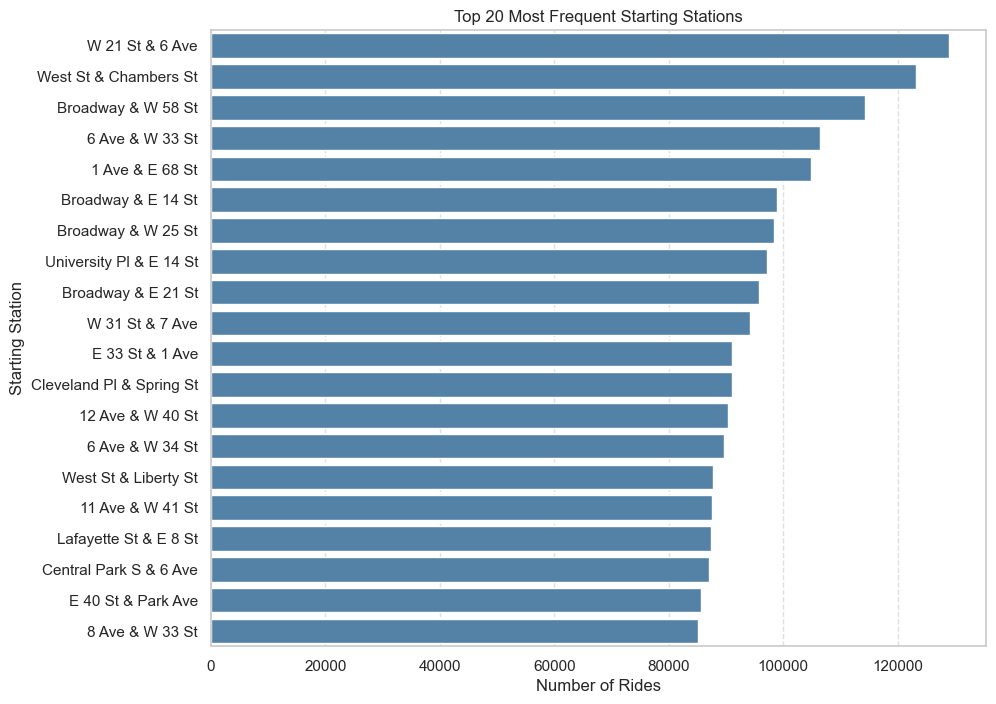

In [12]:
plt.figure(figsize=(10, 8))

sns.barplot(
    data=top_20_stations,
    x="ride_count",
    y="start_station",
    color="steelblue"   
)

plt.title("Top 20 Most Frequent Starting Stations")
plt.xlabel("Number of Rides")
plt.ylabel("Starting Station")

plt.show()

The global color palette does not make sense for this plot because it does not contain enough meaningful colors for 20 categories. Since color does not represent a variable here, I temporarily used a single neutral color so that station frequency is communicated through bar length rather than color.

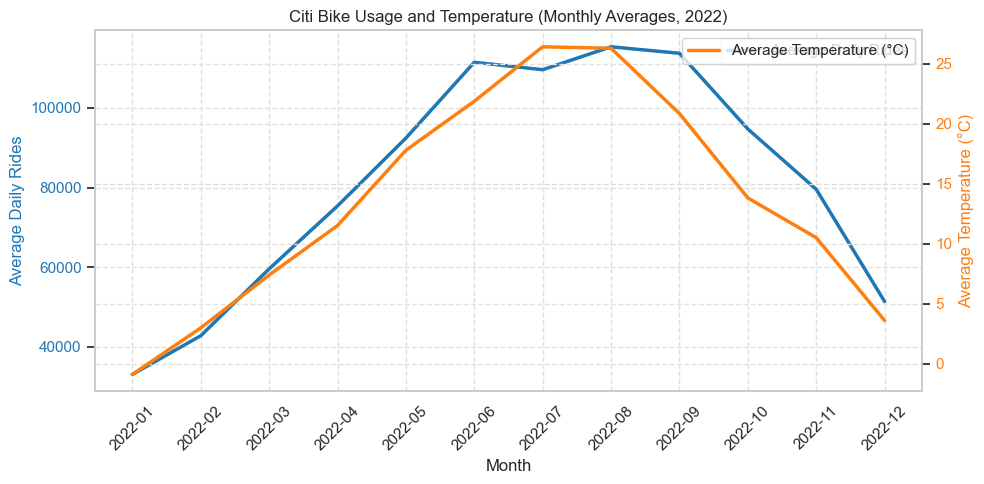

In [45]:
# datetime columns
bike["started_at"] = pd.to_datetime(bike["started_at"], errors="coerce")
weather["date"] = pd.to_datetime(weather["date"], errors="coerce")


weather["avg_temp_c"] = (weather["TMAX"] + weather["TMIN"]) / 2

# Create daily ride counts
daily_rides = (
    bike.dropna(subset=["started_at"])
        .assign(date=lambda df: df["started_at"].dt.floor("D"))
        .groupby("date")
        .size()
        .reset_index(name="trip_count")
)

# Daily weather
daily_weather = weather[["date", "avg_temp_c"]].dropna()

# Merge daily datasets
merged_daily = daily_rides.merge(daily_weather, on="date", how="inner")


merged_daily["month"] = merged_daily["date"].dt.to_period("M").astype(str)

monthly = (
    merged_daily
    .groupby("month")
    .agg(
        rides=("trip_count", "mean"),
        avg_temp=("avg_temp_c", "mean")
    )
    .reset_index()
)

# ----- Plot (dual-axis, seaborn style) -----
fig, ax1 = plt.subplots(figsize=(10, 5))

# Left axis: rides
sns.lineplot(
    data=monthly,
    x="month",
    y="rides",
    ax=ax1,
    label="Average Daily Rides",
    color="#1f77b4"
)
ax1.set_xlabel("Month")
ax1.set_ylabel("Average Daily Rides", color="#1f77b4")
ax1.tick_params(axis="y", labelcolor="#1f77b4")
ax1.tick_params(axis="x", rotation=45)

# Right axis: temperature
ax2 = ax1.twinx()
sns.lineplot(
    data=monthly,
    x="month",
    y="avg_temp",
    ax=ax2,
    label="Average Temperature (°C)",
    color="#ff7f0e"
)
ax2.set_ylabel("Average Temperature (°C)", color="#ff7f0e")
ax2.tick_params(axis="y", labelcolor="#ff7f0e")

plt.title("Citi Bike Usage and Temperature (Monthly Averages, 2022)")
fig.tight_layout()
plt.show()

In [42]:
# Create ride length in minutes 
bike["ended_at"] = pd.to_datetime(bike["ended_at"], errors="coerce")
bike["ride_length"] = (bike["ended_at"] - bike["started_at"]).dt.total_seconds() / 60

# Remove invalid or extreme values
bike_box = bike[
    (bike["ride_length"] > 0) & (bike["ride_length"] <= 180)
].copy()

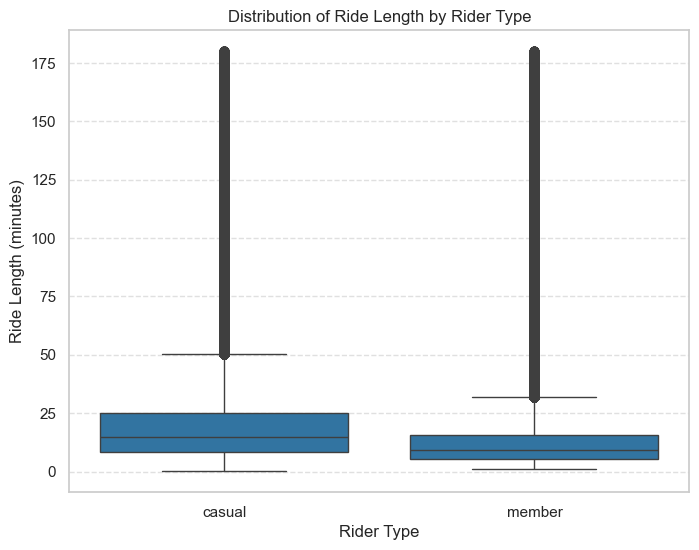

In [44]:
plt.figure(figsize=(8, 6))
#step 6
sns.boxplot(
    data=bike_box,
    x="member_casual",
    y="ride_length"
)

plt.title("Distribution of Ride Length by Rider Type")
plt.xlabel("Rider Type")
plt.ylabel("Ride Length (minutes)")
plt.show()

The box plot shows that casual riders generally have longer ride durations than member riders, as indicated by a higher median. Casual riders also display a wider interquartile range, showing greater variability in trip length. The presence of more outliers among casual riders suggests they are more likely to take unusually long rides.

In [8]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from pathlib import Path

In [10]:
 from pathlib import Path

candidates = sorted([p for p in Path(".").rglob("*.csv") if "weather" not in p.name.lower()])

if not candidates:
    raise FileNotFoundError("No CSV files found. Put your Citi Bike CSV in this project folder.")

print("Using:", candidates[0])
bike = pd.read_csv(candidates[0], low_memory=False)

Using: 2022-citibike-tripdata/202201-citibike-tripdata_1.csv


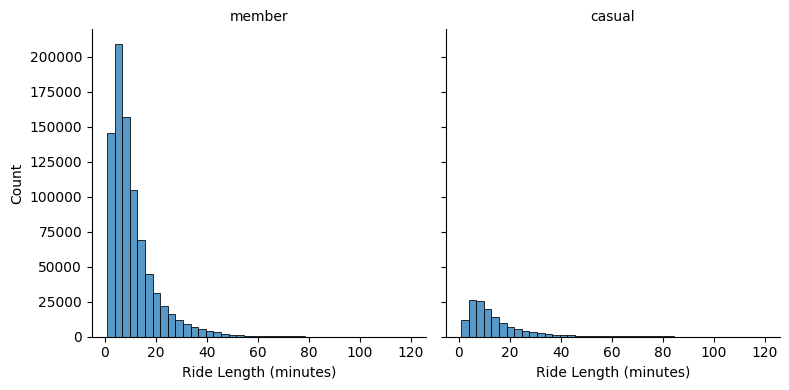

In [11]:

bike["started_at"] = pd.to_datetime(bike["started_at"], errors="coerce")
bike["ended_at"] = pd.to_datetime(bike["ended_at"], errors="coerce")

# Ride length in minutes
bike["ride_length"] = (bike["ended_at"] - bike["started_at"]).dt.total_seconds() / 60

# Clean readable distribution remove negatives + extreme outliers + missing rider type
bike_fg = bike.dropna(subset=["ride_length", "member_casual"])
bike_fg = bike_fg[(bike_fg["ride_length"] > 0) & (bike_fg["ride_length"] <= 120)]

# FacetGrid: distribution of ride length by rider type
g = sns.FacetGrid(bike_fg, col="member_casual", height=4, aspect=1)
g.map_dataframe(sns.histplot, x="ride_length", bins=40)

g.set_axis_labels("Ride Length (minutes)", "Count")
g.set_titles(col_template="{col_name}")
plt.tight_layout()
plt.show()

The FacetGrid shows that ride lengths for both members and casual riders are right-skewed, meaning most trips are short. Member rides are more tightly concentrated at shorter durations, while casual riders show a wider spread with relatively longer trips, suggesting more recreational use.